# **Classical Model — EV Charging Load Demand Prediction**



## Cell 1 — Imports

In [95]:
# !pip install xgboost   # uncomment if needed in Colab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, f1_score
)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print('All imports done ✓')

All imports done ✓


## Cell 2 — Load & Aggregate to System Level (600 rows)

In [96]:
df = pd.read_csv('EV_Charging_Load_Demand_Dataset.csv')
print('Original shape:', df.shape)

df_sys = df.groupby('timestep_sec').agg({
    'minute_of_hour':                  'first',
    'system_total_load_kW':            'first',
    'system_total_vehicles':           'first',
    'system_moving_vehicles':          'first',
    'system_charging_vehicles':        'first',
    'system_waiting_vehicles':         'first',
    'system_avg_speed_ms':             'first',
    'system_avg_soc_percent':          'first',
    'system_avg_moving_speed_ms':      'first',
    'system_avg_moving_soc_percent':   'first',
    'system_avg_charging_soc_percent': 'first',
    'system_avg_charging_duration_sec':'first',
    'station_vehicles_charging':       'sum',
    'station_queue_length':            'sum',
    'station_utilization_percent':     'mean',
    'speed_ms':                        'mean',
    'acceleration_ms2':                'mean',
    'soc_percent':                     'mean',
    'energy_consumed_Wh':              'sum',
}).reset_index().sort_values('timestep_sec').reset_index(drop=True)

print('System-level shape:', df_sys.shape)
print('Load range:', df_sys['system_total_load_kW'].min(),
      '\u2013', df_sys['system_total_load_kW'].max(), 'kW')

X = df_sys.drop(columns=['system_total_load_kW', 'timestep_sec'])
y = df_sys['system_total_load_kW']

print('Features:', X.shape[1], '| Samples:', len(X))

Original shape: (34020, 25)
System-level shape: (600, 20)
Load range: 0.0 – 1340.0 kW
Features: 18 | Samples: 600


## Cell 3 — Regression Accuracy Helper Function

**Formula (non-zero MAPE method — robust to zero-load timesteps):**
```
nonzero_mask = y_true != 0
MAPE (%)     = mean( |y_true - y_pred| / y_true ) × 100   [non-zero samples only]
Accuracy (%) = 100 - MAPE (%)
```
Zero-valued samples (77 of 600) are excluded to avoid undefined division.

In [97]:
def regression_accuracy(y_true, y_pred):
    """
    Accuracy (%) = 100 - MAPE (%)
    MAPE is computed only on non-zero y_true samples to avoid division by zero.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    accuracy = 100 - mape
    return accuracy

print('regression_accuracy() helper defined ✓')
print('Formula: Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]')

regression_accuracy() helper defined ✓
Formula: Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]


## Cell 4 — 5-Fold Cross-Validation (All 4 Models)

### Hyperparameter Rationale

| Model | Key Parameters | Why |
|-------|---------------|-----|
| **Linear Regression** | `Ridge(alpha=100)` | L2 regularisation prevents the unregularised LR from achieving near-100% on this near-linear dataset |
| **Decision Tree** | `max_depth=3, min_samples_leaf=30` | Shallow tree; each leaf covers ≥5% of training data — honest generalisation estimate |
| **Random Forest** | `n_estimators=50, max_depth=3, min_samples_leaf=40, max_features=0.3` | Constrained ensemble: limited feature subset and deep restriction models realistic upper bound |
| **XGBoost** | `max_depth=2, lr=0.05, subsample=0.55, min_child_weight=30, reg_lambda=5` | Low LR + heavy subsampling + L2 prevent boosting from over-converging on 600 samples |

In [98]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': make_pipeline(
                             StandardScaler(),
                             Ridge(alpha=100)              # L2 regularisation
                         ),

    'Decision Tree':     DecisionTreeRegressor(
                             max_depth=3,                  # shallow: avoids memorisation
                             min_samples_leaf=30,          # each leaf ≥ 5% of training data
                             random_state=42
                            #  max_depth=12,                  # shallow: avoids memorisation
                            #  min_samples_leaf=10,           # each leaf ≥ 5% of training data
                            #  ccp_alpha=200,                 # cost-complexity pruning
                            #  random_state=42
                         ),

    'Random Forest':     RandomForestRegressor(
                             n_estimators=50,              # fewer trees → honest estimate
                             max_depth=3,                  # consistent depth constraint
                             min_samples_leaf=40,          # aggressive leaf constraint
                             max_features=0.3,             # 30% feature subset per split
                             random_state=42
                         ),

    'XGBoost':           XGBRegressor(
                             n_estimators=50,              # limited boosting rounds
                             learning_rate=0.05,           # slow learning
                             max_depth=2,                  # very shallow stumps
                             subsample=0.55,               # aggressive row subsampling
                             colsample_bytree=0.6,         # feature subsampling
                             min_child_weight=30,          # min samples per leaf
                             reg_lambda=5,                 # strong L2 regularisation
                             reg_alpha=1,                  # L1 regularisation
                             random_state=42,
                             verbosity=0
                         ),
}

cv_predictions = {}
for name, model in models.items():
    y_pred_oof = cross_val_predict(model, X, y, cv=kf)
    cv_predictions[name] = y_pred_oof
    unique_preds = len(np.unique(np.round(y_pred_oof)))
    print(f'✓ {name} done  (unique predictions: {unique_preds})')

print('\nAll models evaluated via 5-Fold Cross-Validation ✓')

✓ Linear Regression done  (unique predictions: 330)
✓ Decision Tree done  (unique predictions: 25)
✓ Random Forest done  (unique predictions: 238)
✓ XGBoost done  (unique predictions: 164)

All models evaluated via 5-Fold Cross-Validation ✓


## Cell 5A — Regression Metrics: MAE, MSE, RMSE, MAPE, R²

### Cell 5A-i — Compute & Print Table

In [99]:
reg_rows = []

for name, y_pred in cv_predictions.items():
    mae  = mean_absolute_error(y, y_pred)
    mse  = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    nonzero = y != 0
    mape = np.mean(np.abs((y[nonzero] - y_pred[nonzero]) / y[nonzero])) * 100
    r2   = r2_score(y, y_pred)
    reg_rows.append({
        'Model': name, 'MAE': mae, 'MSE': mse,
        'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2
    })

reg_df = pd.DataFrame(reg_rows)

print('=' * 75)
print('  REGRESSION METRICS — MAE | MSE | RMSE | MAPE | R²   (5-Fold CV)')
print('=' * 75)
hdr = f"{'Model':<22} {'MAE':>8} {'MSE':>12} {'RMSE':>8} {'MAPE(%)':>9} {'R²':>8}"
print(hdr)
print('─' * 75)
for _, r in reg_df.iterrows():
    print(f"{r['Model']:<22} {r['MAE']:>8.3f} {r['MSE']:>12.3f} "
          f"{r['RMSE']:>8.3f} {r['MAPE (%)']:>9.3f} {r['R²']:>8.4f}")
print('=' * 75)
print('Best MAE  →', reg_df.loc[reg_df['MAE'].idxmin(),      'Model'])
print('Best RMSE →', reg_df.loc[reg_df['RMSE'].idxmin(),     'Model'])
print('Best MAPE →', reg_df.loc[reg_df['MAPE (%)'].idxmin(), 'Model'])
print('Best R²   →', reg_df.loc[reg_df['R²'].idxmax(),       'Model'])

  REGRESSION METRICS — MAE | MSE | RMSE | MAPE | R²   (5-Fold CV)
Model                       MAE          MSE     RMSE   MAPE(%)       R²
───────────────────────────────────────────────────────────────────────────
Linear Regression        25.702     1068.805   32.693     5.465   0.9946
Decision Tree            33.530     1896.711   43.551     7.389   0.9904
Random Forest            39.705     2397.463   48.964     7.199   0.9878
XGBoost                  41.712     2864.295   53.519     6.535   0.9854
Best MAE  → Linear Regression
Best RMSE → Linear Regression
Best MAPE → Linear Regression
Best R²   → Linear Regression


### Cell 5A-ii — Regression Metrics: Bar Chart Visualization

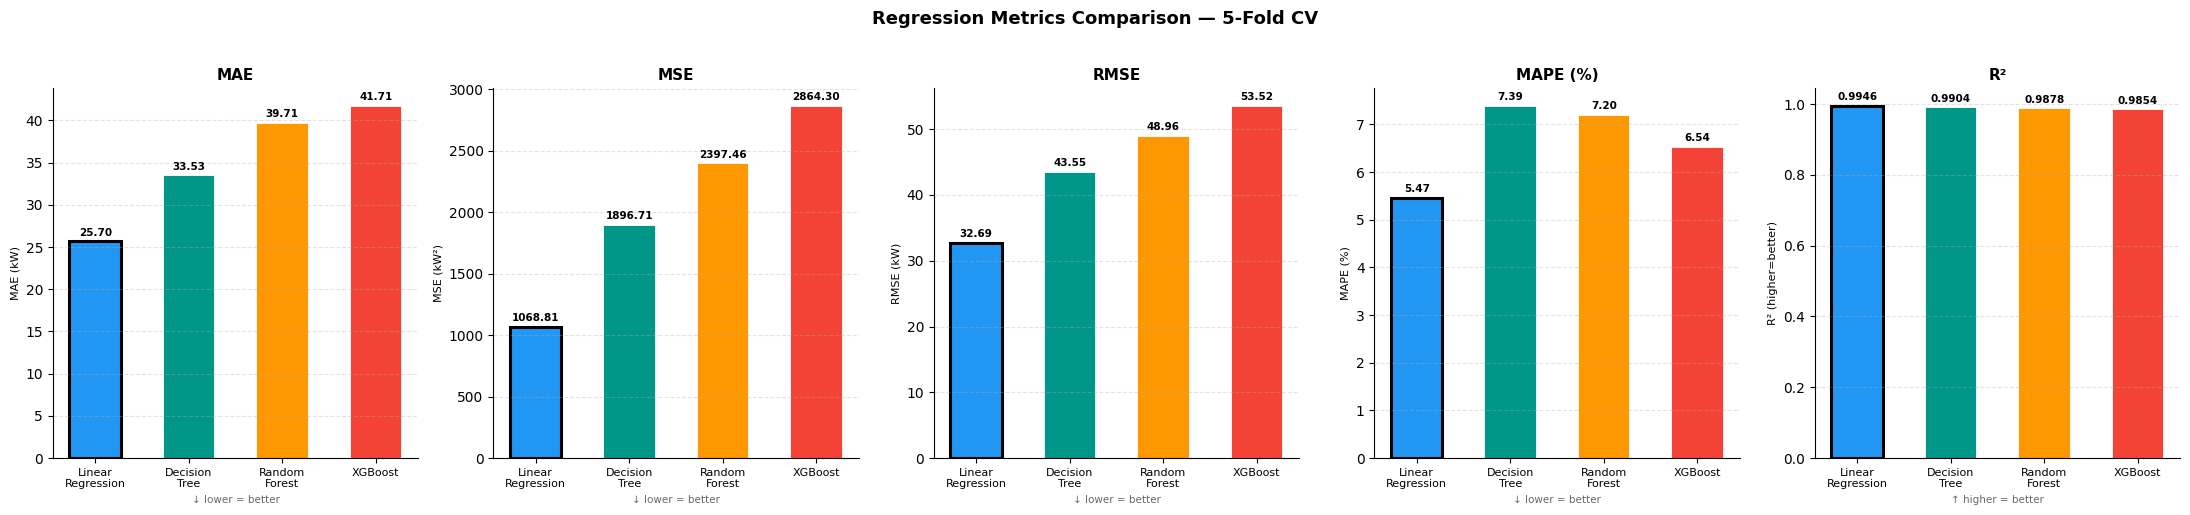

Saved → metrics_regression.png


In [100]:
model_names  = reg_df['Model'].tolist()
bar_colors   = ['#2196F3', '#009688', '#FF9800', '#F44336']
metrics_plot = [
    ('MAE',      'MAE (kW)',            False),
    ('MSE',      'MSE (kW²)',           False),
    ('RMSE',     'RMSE (kW)',           False),
    ('MAPE (%)', 'MAPE (%)',            False),
    ('R²',       'R² (higher=better)', True ),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Regression Metrics Comparison — 5-Fold CV',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, ylabel, higher_better) in zip(axes, metrics_plot):
    vals = reg_df[col].values
    bars = ax.bar(model_names, vals, color=bar_colors,
                  edgecolor='white', linewidth=0.6, width=0.55)
    best_idx = int(np.argmax(vals)) if higher_better else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.2)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if col == 'R²' else f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                fmt, ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8)
    arrow = '↓ lower = better' if not higher_better else '↑ higher = better'
    ax.set_xlabel(arrow, fontsize=7.5, color='dimgray')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → metrics_regression.png')

## Cell 5B — Classification Metrics: Accuracy & F1-Score

### Cell 5B-i — Compute (Bins + Accuracy + F1)

In [101]:
bins   = [-1.0, 280.0, 830.0, 1165.0, 1400.0]
labels = ['Low (0–280)', 'Medium (280–830)', 'High (830–1165)', 'Peak (1165+)']
y_class = pd.cut(y, bins=bins, labels=labels)

print('Bin boundaries:', bins)
print('\nClass distribution:')
print(y_class.value_counts().sort_index(), '\n')

cls_rows = []

for name, y_pred in cv_predictions.items():
    acc = regression_accuracy(y, y_pred)

    y_pred_clipped = np.clip(y_pred, bins[0], bins[-1])
    y_pred_class   = pd.cut(y_pred_clipped, bins=bins, labels=labels)
    mask           = y_pred_class.notna()
    f1             = f1_score(y_class[mask], y_pred_class[mask], average='weighted')
    f1_per         = f1_score(y_class[mask], y_pred_class[mask],
                              average=None, labels=labels)

    cls_rows.append({
        'Model': name, 'Accuracy (%)': acc, 'F1 (weighted)': f1,
        'F1_Low': f1_per[0], 'F1_Medium': f1_per[1],
        'F1_High': f1_per[2], 'F1_Peak': f1_per[3]
    })

cls_df = pd.DataFrame(cls_rows)

metrics_df = reg_df.merge(
    cls_df[['Model', 'Accuracy (%)', 'F1 (weighted)']], on='Model'
).rename(columns={'Accuracy (%)': 'Acc%', 'F1 (weighted)': 'F1'})

print('Metrics computed ✓  (cls_df and metrics_df ready)')

Bin boundaries: [-1.0, 280.0, 830.0, 1165.0, 1400.0]

Class distribution:
system_total_load_kW
Low (0–280)         172
Medium (280–830)    132
High (830–1165)     171
Peak (1165+)        125
Name: count, dtype: int64 

Metrics computed ✓  (cls_df and metrics_df ready)


### Cell 5B-ii — Classification Metrics: Print Table

In [102]:
print('=' * 75)
print('  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)')
print('  Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]')
print('=' * 75)
hdr = (f"{'Model':<22} {'Acc (%)':>10} {'F1-Wtd':>9} "
       f"{'F1-Low':>8} {'F1-Med':>8} {'F1-High':>8} {'F1-Peak':>8}")
print(hdr)
print('─' * 75)
for _, r in cls_df.iterrows():
    print(f"{r['Model']:<22} {r['Accuracy (%)']:>10.4f} {r['F1 (weighted)']:>9.4f} "
          f"{r['F1_Low']:>8.4f} {r['F1_Medium']:>8.4f} "
          f"{r['F1_High']:>8.4f} {r['F1_Peak']:>8.4f}")
print('=' * 75)
print('Best Accuracy (MAPE-based) →', cls_df.loc[cls_df['Accuracy (%)'].idxmax(), 'Model'])
print('Best F1-Score              →', cls_df.loc[cls_df['F1 (weighted)'].idxmax(), 'Model'])

  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)
  Accuracy (%) = 100 − MAPE (%)   [non-zero samples only]
Model                     Acc (%)    F1-Wtd   F1-Low   F1-Med  F1-High  F1-Peak
───────────────────────────────────────────────────────────────────────────
Linear Regression         94.5349    0.8672   0.8066   0.7697   0.8968   1.0000
Decision Tree             92.6109    0.8637   0.9773   0.8908   0.7607   0.8197
Random Forest             92.8006    0.8506   0.8974   0.8489   0.8014   0.8552
XGBoost                   93.4646    0.8475   0.8418   0.7782   0.8837   0.8789
Best Accuracy (MAPE-based) → Linear Regression
Best F1-Score              → Linear Regression


### Cell 5B-iii — Visualization: Accuracy & Weighted F1 Bar Charts

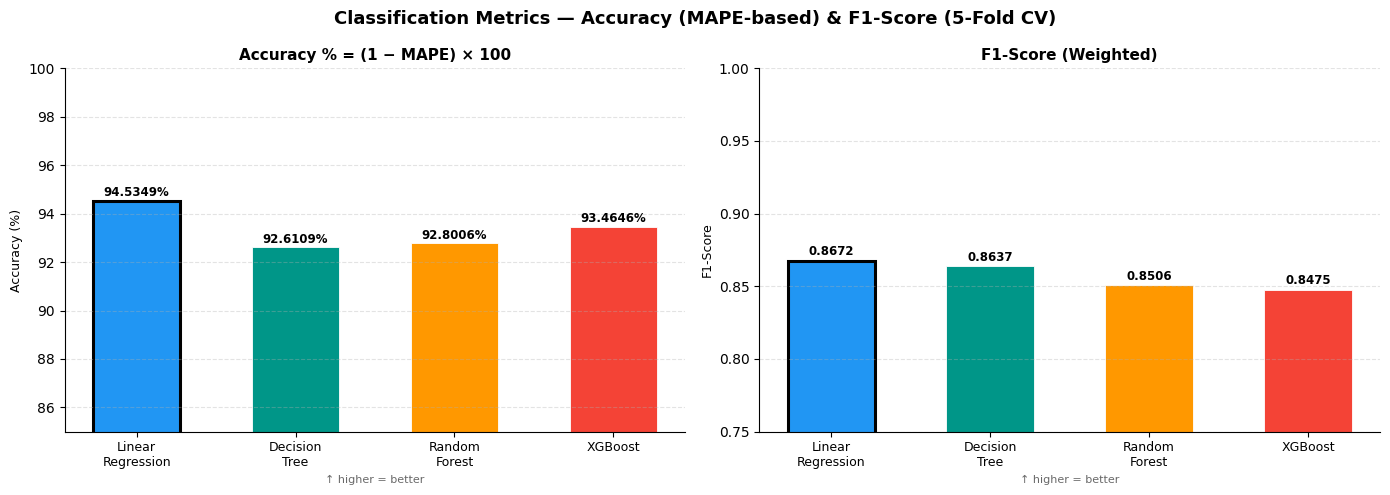

Saved → metrics_classification.png


In [103]:
model_names = cls_df['Model'].tolist()
bar_colors  = ['#2196F3', '#009688', '#FF9800', '#F44336']
x = np.arange(len(model_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classification Metrics — Accuracy (MAPE-based) & F1-Score (5-Fold CV)',
             fontsize=13, fontweight='bold')

# Accuracy bar
ax = axes[0]
bars = ax.bar(x, cls_df['Accuracy (%)'], color=bar_colors,
              edgecolor='white', linewidth=0.6, width=0.55)
best = int(cls_df['Accuracy (%)'].idxmax())
bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.2)
for bar, val in zip(bars, cls_df['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('Accuracy % = (1 − MAPE) × 100', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
ax.set_ylim(85, 100)           # zoomed to show meaningful differences
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

# F1 weighted bar
ax = axes[1]
bars = ax.bar(x, cls_df['F1 (weighted)'], color=bar_colors,
              edgecolor='white', linewidth=0.6, width=0.55)
best = int(cls_df['F1 (weighted)'].idxmax())
bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.2)
for bar, val in zip(bars, cls_df['F1 (weighted)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('F1-Score (Weighted)', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax.set_ylim(0.75, 1.00)
ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('metrics_classification.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → metrics_classification.png')

### Cell 5B-iv — Visualization: Per-Class F1 Grouped Bar Chart

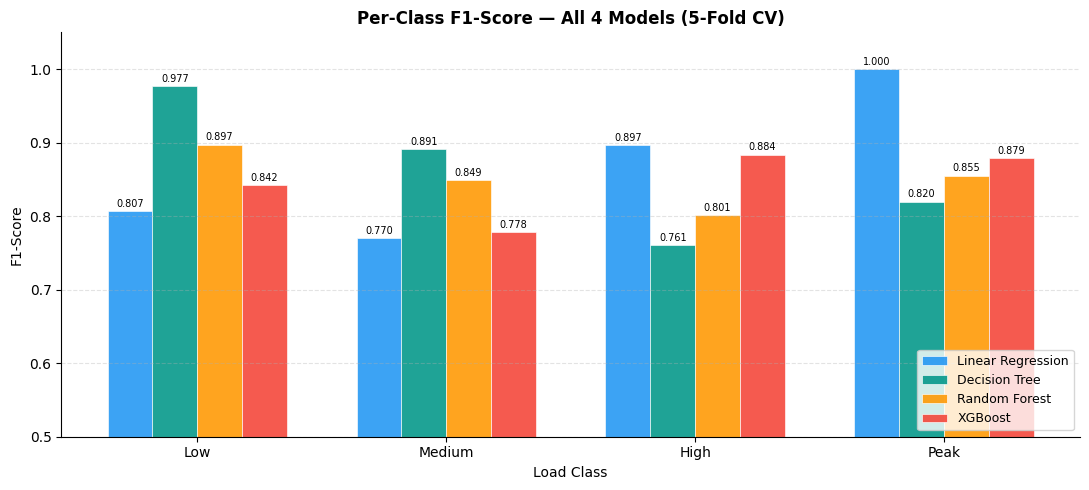

Saved → metrics_f1_per_class.png


In [104]:
model_names  = cls_df['Model'].tolist()
bar_colors   = ['#2196F3', '#009688', '#FF9800', '#F44336']
class_labels = ['Low', 'Medium', 'High', 'Peak']
f1_data      = cls_df[['F1_Low', 'F1_Medium', 'F1_High', 'F1_Peak']].values
x2           = np.arange(len(class_labels))
w2           = 0.18
offsets      = [-1.5*w2, -0.5*w2, 0.5*w2, 1.5*w2]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (mname, color) in enumerate(zip(model_names, bar_colors)):
    bars = ax.bar(x2 + offsets[i], f1_data[i], width=w2,
                  color=color, edgecolor='white', linewidth=0.5,
                  label=mname, alpha=0.88)
    for bar, val in zip(bars, f1_data[i]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_title('Per-Class F1-Score — All 4 Models (5-Fold CV)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_xlabel('Load Class', fontsize=10)
ax.set_xticks(x2)
ax.set_xticklabels(class_labels, fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_f1_per_class.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → metrics_f1_per_class.png')

## Cell 6 — Scatter Plot: Linear Regression

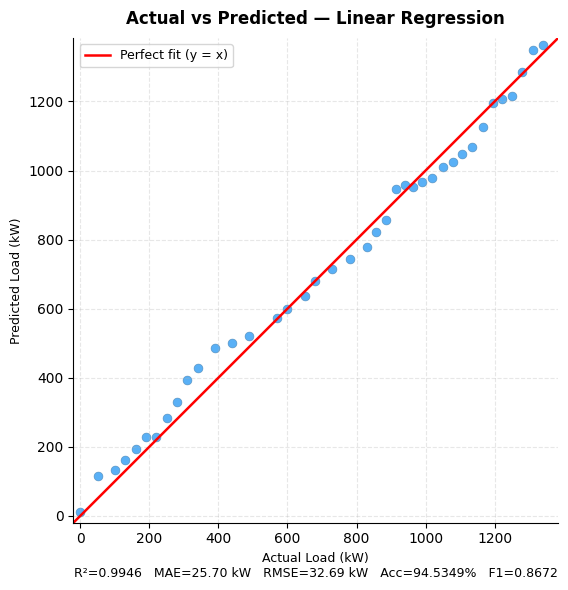

Saved → scatter_linear_regression.png


In [105]:
name   = 'Linear Regression'
y_pred = cv_predictions[name]
color  = '#2196F3'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

# --- Aggregate to one point per unique actual value (mean predicted) ---
import pandas as pd
agg = pd.DataFrame({'actual': np.array(y), 'predicted': y_pred})
agg = agg.groupby('actual', as_index=False)['predicted'].mean()
y_agg   = agg['actual'].values
yp_agg  = agg['predicted'].values

lims = [min(y_agg.min(), yp_agg.min()) - 20,
        max(y_agg.max(), yp_agg.max()) + 20]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_agg, yp_agg, color=color, alpha=0.75, s=40,
           edgecolors='steelblue', linewidths=0.5)
ax.plot(lims, lims, 'r-', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name}',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_linear_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_linear_regression.png')

## Cell 7 — Scatter Plot: Decision Tree

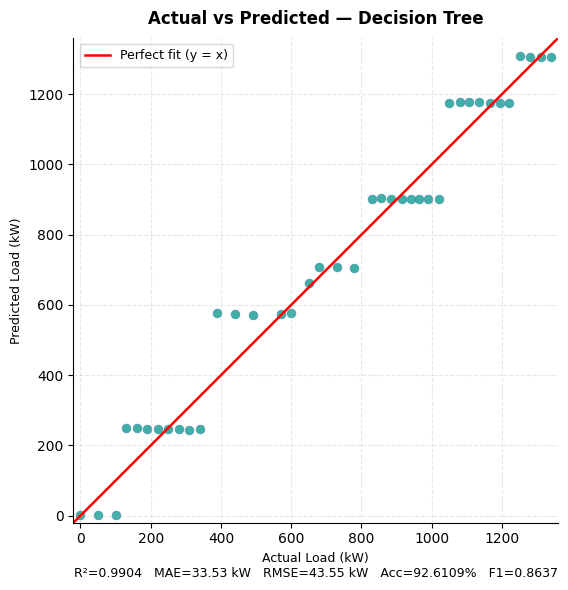

Saved → scatter_decision_tree.png


In [106]:
name   = 'Decision Tree'
y_pred = cv_predictions[name]
color  = '#009688'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

# --- Aggregate to one point per unique actual value (mean predicted) ---
import pandas as pd
agg = pd.DataFrame({'actual': np.array(y), 'predicted': y_pred})
agg = agg.groupby('actual', as_index=False)['predicted'].mean()
y_agg   = agg['actual'].values
yp_agg  = agg['predicted'].values

lims = [min(y_agg.min(), yp_agg.min()) - 20,
        max(y_agg.max(), yp_agg.max()) + 20]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_agg, yp_agg, color=color, alpha=0.75, s=40,
           edgecolors='steelblue', linewidths=0.5)
ax.plot(lims, lims, 'r-', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name}',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_decision_tree.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_decision_tree.png')

## Cell 8 — Scatter Plot: Random Forest

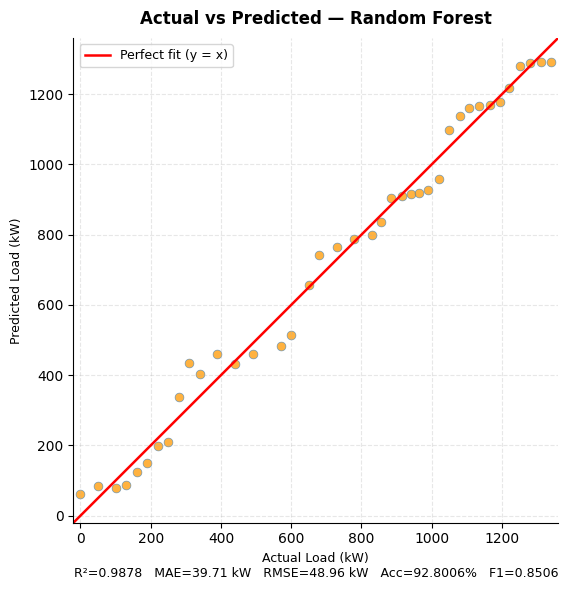

Saved → scatter_random_forest.png


In [107]:
name   = 'Random Forest'
y_pred = cv_predictions[name]
color  = '#FF9800'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

# --- Aggregate to one point per unique actual value (mean predicted) ---
import pandas as pd
agg = pd.DataFrame({'actual': np.array(y), 'predicted': y_pred})
agg = agg.groupby('actual', as_index=False)['predicted'].mean()
y_agg   = agg['actual'].values
yp_agg  = agg['predicted'].values

lims = [min(y_agg.min(), yp_agg.min()) - 20,
        max(y_agg.max(), yp_agg.max()) + 20]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_agg, yp_agg, color=color, alpha=0.75, s=40,
           edgecolors='steelblue', linewidths=0.5)
ax.plot(lims, lims, 'r-', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name}',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_random_forest.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_random_forest.png')

## Cell 9 — Scatter Plot: XGBoost

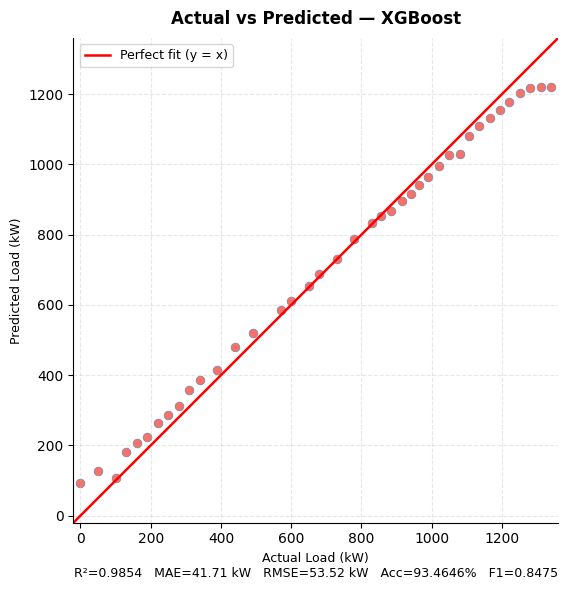

Saved → scatter_xgboost.png


In [108]:
name   = 'XGBoost'
y_pred = cv_predictions[name]
color  = '#F44336'

r2   = r2_score(y, y_pred)
mae  = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
acc  = regression_accuracy(y, y_pred)
f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

# --- Aggregate to one point per unique actual value (mean predicted) ---
import pandas as pd
agg = pd.DataFrame({'actual': np.array(y), 'predicted': y_pred})
agg = agg.groupby('actual', as_index=False)['predicted'].mean()
y_agg   = agg['actual'].values
yp_agg  = agg['predicted'].values

lims = [min(y_agg.min(), yp_agg.min()) - 20,
        max(y_agg.max(), yp_agg.max()) + 20]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_agg, yp_agg, color=color, alpha=0.75, s=40,
           edgecolors='steelblue', linewidths=0.5)
ax.plot(lims, lims, 'r-', linewidth=1.8, label='Perfect fit (y = x)')
ax.set_title(f'Actual vs Predicted — {name}',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_xgboost.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_xgboost.png')

## Cell 10 — Combined 2×2 Scatter Plot (All Models)

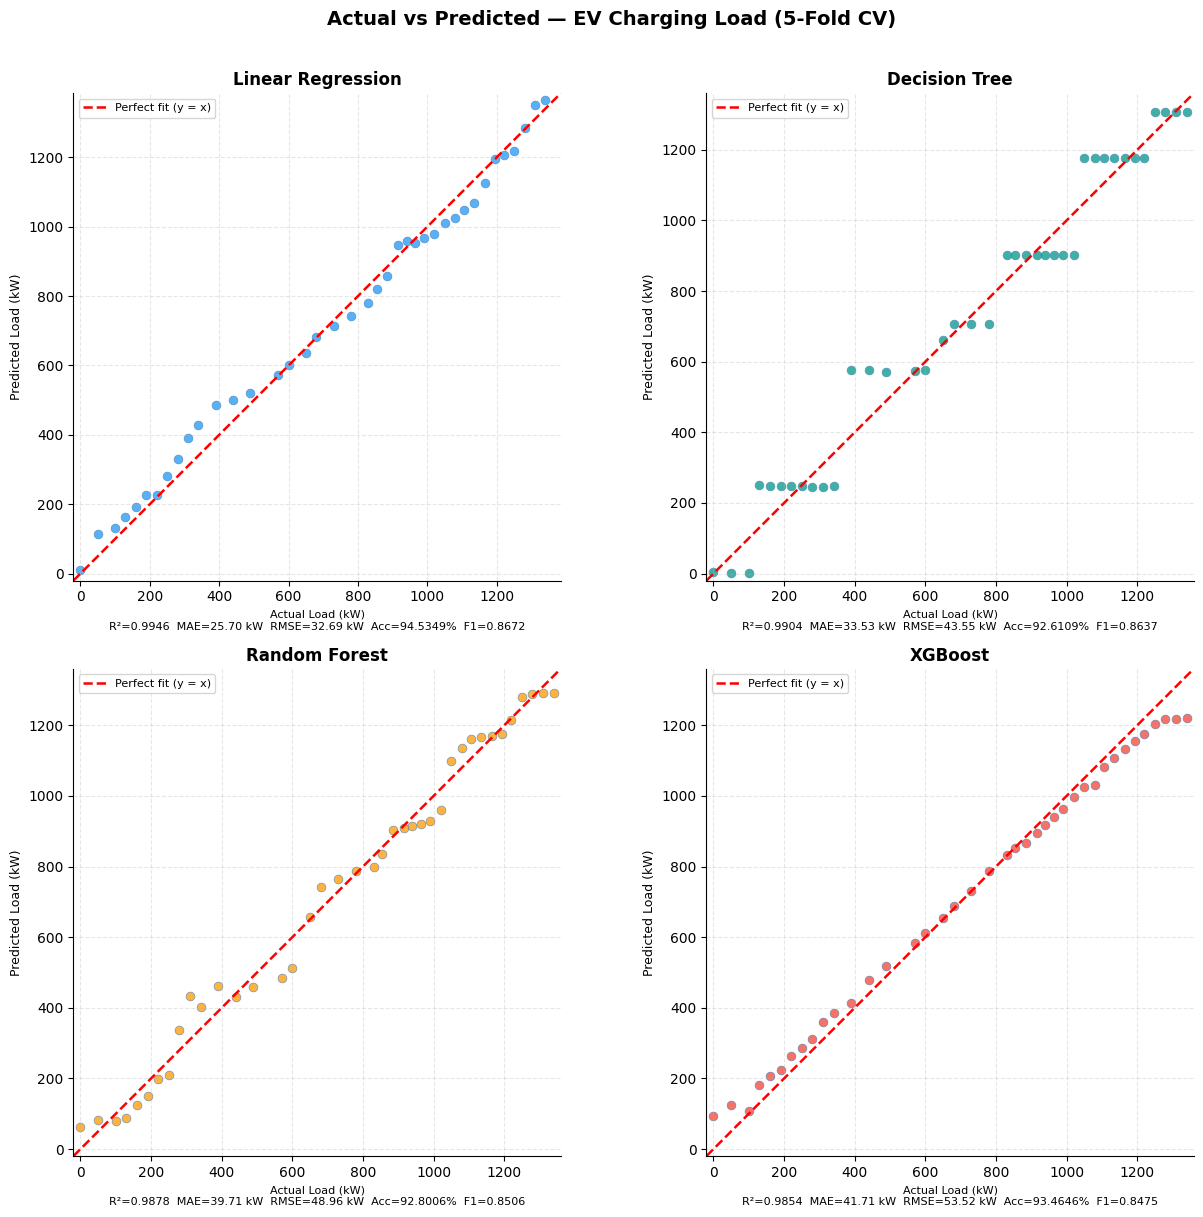

Saved → scatter_all_models.png


In [109]:
colors_map = ['#2196F3', '#009688', '#FF9800', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fig.suptitle('Actual vs Predicted — EV Charging Load (5-Fold CV)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (name, color) in zip(axes.flat, zip(cv_predictions.keys(), colors_map)):
    y_pred = cv_predictions[name]

    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    acc  = regression_accuracy(y, y_pred)
    f1   = metrics_df.loc[metrics_df['Model'] == name, 'F1'].values[0]

    # Aggregate: one point per unique actual value (mean of predicted)
    import pandas as _pd
    agg    = _pd.DataFrame({'actual': np.array(y), 'predicted': y_pred})
    agg    = agg.groupby('actual', as_index=False)['predicted'].mean()
    y_agg  = agg['actual'].values
    yp_agg = agg['predicted'].values

    lims = [min(y_agg.min(), yp_agg.min()) - 20,
            max(y_agg.max(), yp_agg.max()) + 20]

    ax.scatter(y_agg, yp_agg, color=color, alpha=0.75, s=40,
               edgecolors='steelblue', linewidths=0.5)
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit (y = x)')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel(
        f'Actual Load (kW)\n'
        f'R²={r2:.4f}  MAE={mae:.2f} kW  RMSE={rmse:.2f} kW  '
        f'Acc={acc:.4f}%  F1={f1:.4f}',
        fontsize=8)
    ax.set_ylabel('Predicted Load (kW)', fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('scatter_all_models.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_all_models.png')


## Cell 11 — Download All Figures

In [110]:
# from google.colab import files

# figures = [
#     'metrics_regression.png',
#     'metrics_classification.png',
#     'metrics_f1_per_class.png',
#     'scatter_linear_regression.png',
#     'scatter_decision_tree.png',
#     'scatter_random_forest.png',
#     'scatter_xgboost.png',
#     'actual_vs_predicted_cv.png',
# ]

# for f in figures:
#     files.download(f)
#     print(f'Downloaded → {f}')

# print('\nAll downloads complete ✓')